In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_rgb, AsinhStretch
from torchvision.transforms import ToPILImage

# load galaxy dataset

In [ ]:
from galaxy_datasets import gz_candels 

catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [ ]:
cols = catalog.columns.to_numpy()

# initial testing

In [ ]:
from ml_sandbox.dataset import load_image
import numpy as np
im = load_image(catalog['filename'][0], dir='.tmp/')


In [ ]:
import torch

In [ ]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
import torch
gzdataset = GalaxyDataset(
    catalog,
    label_cols=['merging-candels_merger'],  
    # transform=ToTensor(),
    target_transform=lambda x: torch.tensor(x, dtype=torch.float32),
    )

In [ ]:
from ml_sandbox.dataset import get_dataset
dataset_tr = get_dataset(catalog, label_cols=['merging-candels_merger'], size=1000, train=True, dir='.tmp/')

In [ ]:
for i in range(10):
    img, label = dataset_tr[i]
    print(f"Max value: {img.max()}, Min value: {img.min()}")

Max value: 5.125636577606201, Min value: -0.6874475479125977
Max value: 10.704015731811523, Min value: -0.6874475479125977
Max value: 5.4087700843811035, Min value: -0.6874475479125977
Max value: 12.31550407409668, Min value: -0.6874475479125977
Max value: 5.788532257080078, Min value: -0.6874475479125977
Max value: 8.950034141540527, Min value: -0.6874475479125977
Max value: 3.654910087585449, Min value: -0.6874475479125977
Max value: 6.908308506011963, Min value: -0.6874475479125977
Max value: 4.105797290802002, Min value: -0.6874475479125977
Max value: 5.783654689788818, Min value: -0.6874475479125977


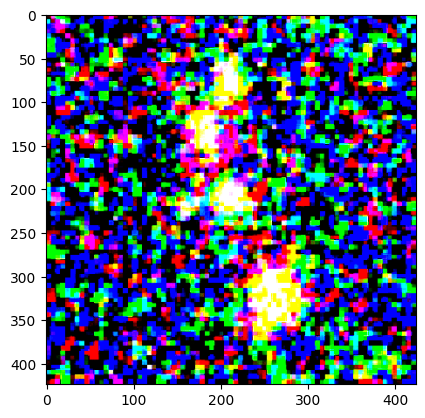

In [ ]:
im, lab = dataset_tr[5]
plt.imshow(im.permute(1,2,0))

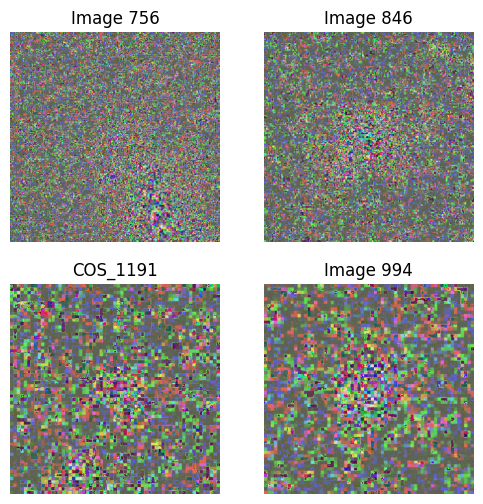

In [ ]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(dataset_tr, num_images=i+1)

# training

In [ ]:
catalog['merging-candels_merger'].max()+1

np.float64(59.0)

In [14]:
from ml_sandbox.models import SimpleCNNClassifier
from ml_sandbox.train_eval import train_cnn, test_cnn
from ml_sandbox.dataset import get_dataloader
from sklearn.model_selection import train_test_split

model = SimpleCNNClassifier(num_classes=int(catalog['merging-candels_merger'].max()+1), input_channels=3, side=424)

train_cat, test_cat = train_test_split(catalog, test_size=0.2, random_state=42)

train_dataset = get_dataset(train_cat, label_cols=['merging-candels_merger'], size=None, train=True, dir='.tmp/')
test_dataset = get_dataset(test_cat, label_cols=['merging-candels_merger'], size=None, train=False, dir='.tmp/')

train_loader = get_dataloader(train_dataset, batch_size=8)
test_loader = get_dataloader(test_dataset, batch_size=8)

from torch.nn import CrossEntropyLoss
criterion = CrossEntropyLoss()

from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=1e-3)

In [17]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    print(labels)
    break

torch.Size([32, 3, 424, 424]) torch.Size([32])
tensor([ 1.,  0.,  2.,  3.,  0.,  1.,  0.,  1., 11.,  0.,  4.,  1.,  0.,  3.,
         3.,  2.,  2.,  0.,  3.,  0.,  5.,  1.,  0.,  0.,  3.,  1., 10.,  1.,
         3.,  1.,  2., 10.])


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

In [19]:
for _ in range(5):
    train_cnn(train_loader, model, criterion, optimizer, device=device) 
    test_cnn(test_loader, model, criterion, device=device)

OutOfMemoryError: CUDA out of memory. Tried to allocate 174.00 MiB. GPU 0 has a total capacity of 1.92 GiB of which 91.12 MiB is free. Including non-PyTorch memory, this process has 802.00 MiB memory in use. Of the allocated memory 761.13 MiB is allocated by PyTorch, and 4.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [18]:
for images, labels in train_loader:
    print(model(images), labels)
    break

tensor([[6.9963e+09],
        [3.4174e+09],
        [2.6189e+09],
        [6.5996e+09],
        [2.2414e+09],
        [2.6561e+09],
        [5.1489e+09],
        [1.9165e+09],
        [2.4844e+09],
        [1.3240e+10],
        [3.0722e+09],
        [2.0281e+09],
        [5.9011e+09],
        [3.7643e+09],
        [1.4227e+09],
        [3.7246e+09]], grad_fn=<AddmmBackward0>) tensor([0., 1., 5., 1., 1., 2., 0., 2., 3., 1., 2., 5., 1., 2., 0., 3.])


In [7]:
from ml_sandbox.models import make_pca_rf_pipeline
model = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [ ]:
from ml_sandbox.dataset import split_sklearn_dataset
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = split_sklearn_dataset(catalog, label_cols='merging-candels_merger')



In [9]:
import torchvision
from torchvision.transforms import ToTensor

In [8]:
model.fit(xtrain, ytrain)
test_accuracy = model.score(xtest, ytest)
print(f'Test Accuracy: {test_accuracy:.4f}')


ValueError: could not convert string to float: 'GDS_2171.jpg'